In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:


df = pd.read_excel("../dataset/Sample - Superstore.xlsx")


In [9]:
df.shape

(9999, 21)

In [6]:
# Add the first 5 rows again
df = pd.concat([df, df.iloc[:5]], ignore_index=True)

In [7]:
df.duplicated().sum()

np.int64(5)

In [8]:
df.shape

(9999, 21)

In [11]:
df.duplicated().sum()

np.int64(5)

In [12]:
duplicates_before = df.duplicated().sum()

In [13]:
df = df.drop_duplicates()

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.shape

(9994, 21)

In [16]:
duplicates_after = df.duplicated().sum()

print("Duplicates before:", duplicates_before)
print("Duplicates after:", duplicates_after)

Duplicates before: 5
Duplicates after: 0


In [17]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [21]:
df = pd.read_excel("../dataset/Sample - Superstore_Duplicates.xlsx")

In [22]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      1
Customer Name    0
Segment          0
Country          1
City             0
State            0
Postal Code      0
Region           1
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         2
Discount         0
Profit           0
dtype: int64

In [ ]:
#addinng missing values to the dataset for testing purposes
df.loc[10, 'Sales'] = None
df.loc[20, 'Profit'] = None
df.loc[30, 'Ship Mode'] = None

In [24]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        1
Customer ID      1
Customer Name    0
Segment          0
Country          1
City             0
State            0
Postal Code      0
Region           1
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            1
Quantity         2
Discount         0
Profit           1
dtype: int64

In [ ]:
#Standardize Text Columns
text_columns = ['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Region', 'Category', 'Sub-Category']

for col in text_columns:
    df[col] = df[col].str.strip().str.title()

In [27]:
df.to_csv("../reports/cleaned_data.csv", index=False)

In [ ]:
#Cleaning missing values
df['Sales'] = df['Sales'].fillna(df['Sales'].mean())
df['Profit'] = df['Profit'].fillna(df['Profit'].mean())
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].mean())
df['Ship Mode'] = df['Ship Mode'].fillna(df['Ship Mode'].mode()[0])
df['Customer ID'] = df['Customer ID'].fillna(df['Customer ID'].mode()[0])

df['Country'] = df['Country'].fillna(df['Country'].mode()[0])

df['Region'] = df['Region'].fillna(df['Region'].mode()[0])

In [29]:
df.to_csv("../reports/cleaned_data.csv", index=False)

In [30]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [31]:
original_rows = 9999
final_rows = 9994
duplicates_removed = 5
missing_values_remaining = df.isnull().sum().sum()

In [33]:
report = f"""
DATA CLEANING REPORT
----------------------------

Original Rows           : {original_rows}
Final Rows              : {final_rows}
Duplicates Removed      : {duplicates_removed}
Missing Values Remaining: {missing_values_remaining}

Cleaning Operations Performed:
✔ Removed duplicate rows
✔ Filled missing values
✔ Standardized text columns
✔ Saved cleaned dataset

Report Generated Successfully.
"""

with open("../reports/cleaning_report.txt", "w", encoding="utf-8") as file:
    file.write(report)

print("Cleaning report generated successfully!")

Cleaning report generated successfully!


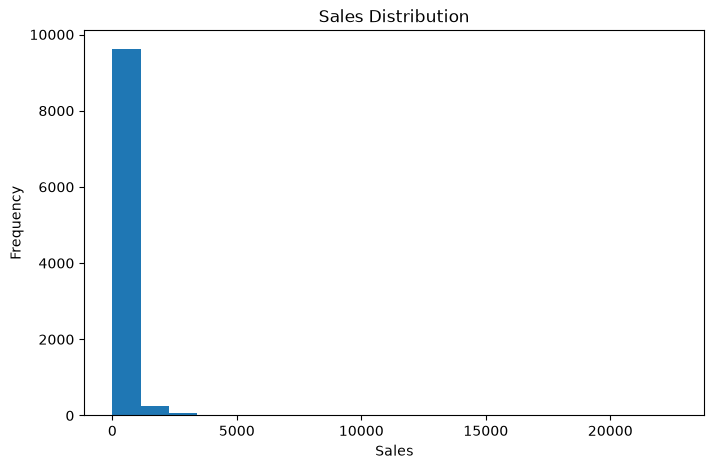

In [35]:
plt.figure(figsize=(8,5))
plt.hist(df['Sales'], bins=20)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.savefig("../images/sales_distribution.png")

plt.show()

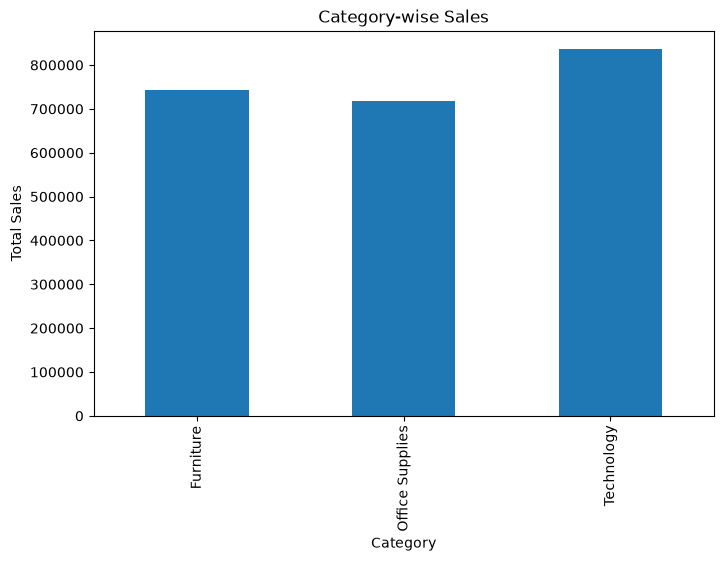

In [36]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')

plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.savefig("../images/category_sales.png")

plt.show()

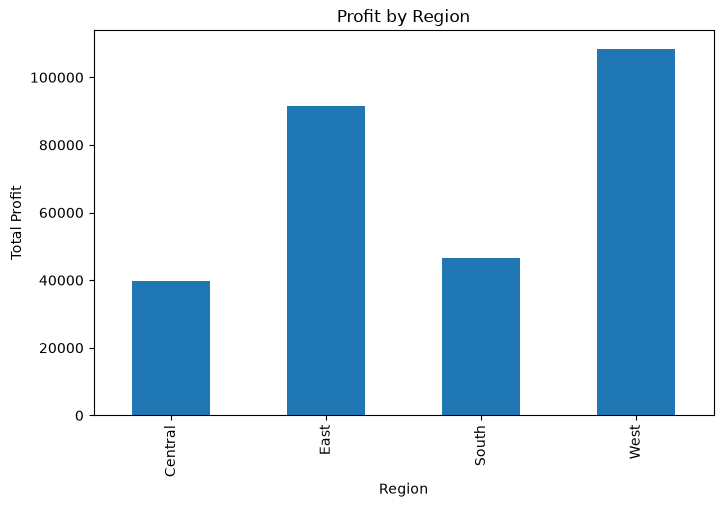

In [37]:
region_profit = df.groupby('Region')['Profit'].sum()

plt.figure(figsize=(8,5))
region_profit.plot(kind='bar')

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.savefig("../images/profit_by_region.png")

plt.show()